In [47]:
import cv2
import matplotlib.pyplot as plt
from patchify import patchify, unpatchify
import pandas as pd
import numpy as np

(-0.5, 4111.5, 3005.5, -0.5)

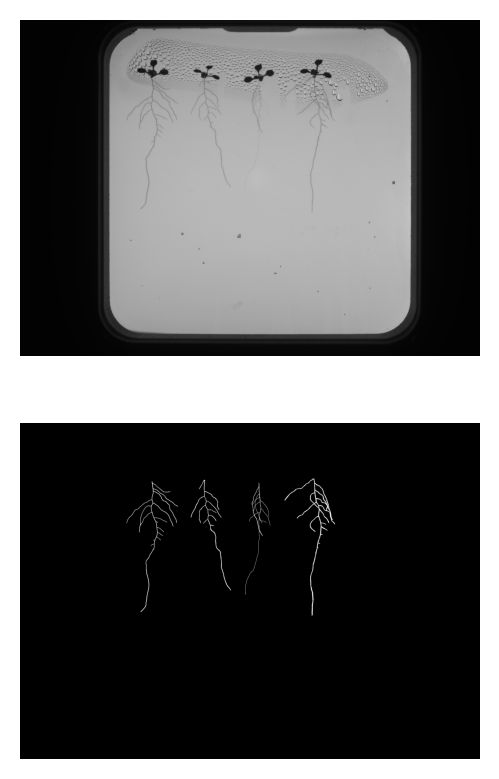

In [48]:
im_path = '../data/processed/dataset_24/train_images/train_Dean_231754_im4.png'

im_mask_path = '../data/processed/dataset_24/train_masks/train_Dean_231754_im4_root_mask.tif'

image = cv2.imread(im_path)
mask = cv2.imread(im_mask_path, 0)

fig, ax = plt.subplots(2, dpi=200)
ax[0].imshow(image)
ax[0].axis('off')
ax[1].imshow(mask, cmap='gray')
ax[1].axis('off')

In [49]:
def detect_and_crop_square(image_path, shrink_pixels=20):
    
    # Read the image
    im = cv2.imread(image_path)
    if im is None:
        print(f"Error: Could not read image {image_path}")
        return None, None

    # Convert to grayscale for processing
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    # Apply Otsu's thresholding to separate foreground from background
    # Otsu automatically determines the optimal threshold value
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Create morphological kernel for cleaning operations
    # Kernel size chosen based on typical petri dish size in images
    kernel = np.ones((20, 20), np.uint8)

    # Apply morphological opening: removes small noise and outliers
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Apply morphological closing: fills small holes inside the petri dish region
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Find all contours in the binary image
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print(f"Warning: No contours found in {image_path}")
        return None, None

    # Select the largest contour, which should be the petri dish
    largest_contour = max(contours, key=cv2.contourArea)

    # Get axis-aligned bounding rectangle around the contour
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Shrink the bounding box inward to avoid including black background pixels
    # This ensures we stay within the petri dish boundaries (±30 pixel tolerance)
    x += shrink_pixels
    y += shrink_pixels
    w -= 2 * shrink_pixels
    h -= 2 * shrink_pixels

    # Force square output by using the maximum dimension
    # This satisfies the requirement: "The output must be a square"
    size = max(w, h)

    # Calculate center point of the bounding box
    center_x = x + w // 2
    center_y = y + h // 2

    # Position the square crop centered on the petri dish
    x_start = center_x - size // 2
    y_start = center_y - size // 2

    # Ensure crop boundaries don't exceed image dimensions
    x_start = max(0, x_start)
    y_start = max(0, y_start)
    x_end = min(im.shape[1], x_start + size)
    y_end = min(im.shape[0], y_start + size)

    # Create visualization: draw green rectangle on original image
    im_with_box = im.copy()
    cv2.rectangle(im_with_box, (x_start, y_start), (x_end, y_end), (0, 255, 0), 5)

    # Crop the square region from original image
    cropped = im[y_start:y_end, x_start:x_end]

    return im_with_box, cropped

In [50]:
_, image = detect_and_crop_square(im_path)

(-0.5, 4111.5, 3005.5, -0.5)

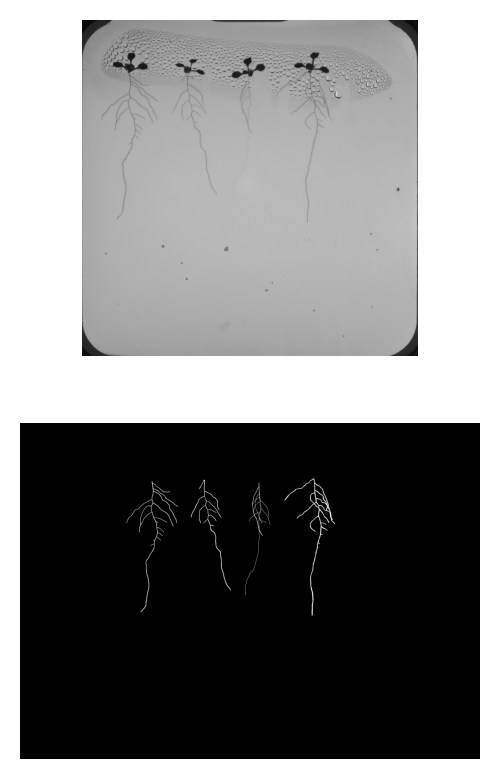

In [51]:
mask = cv2.imread(im_mask_path, 0)

fig, ax = plt.subplots(2, dpi=200)
ax[0].imshow(image)
ax[0].axis('off')
ax[1].imshow(mask, cmap='gray')
ax[1].axis('off')

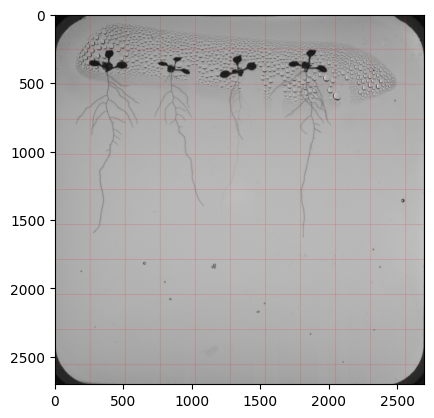

In [52]:
image_with_grid = image.copy()

patch_size = 256

height, width = image_with_grid.shape[:2]

for x in range(0, height, patch_size):
    cv2.line(image_with_grid, (x, 0), (x, width), (255, 0, 0), 1)

for y in range(0, width, patch_size):
    cv2.line(image_with_grid, (0, y), (width, y), (255, 0, 0), 1)

plt.imshow(image_with_grid)

In [ ]:
def calculate_padding(image, patch_size=256, overlap=0.5):
    
    h, w = image.shape[:2]
    stride = int(patch_size * (1 - overlap))
    
    h_pad = (stride - (h - patch_size) % stride) % stride
    w_pad = (stride - (w - patch_size) % stride) % stride

    top_pad = h_pad // 2
    bottom_pad = h_pad - top_pad
    left_pad = w_pad // 2
    right_pad = w_pad - left_pad
    
    return top_pad, bottom_pad, left_pad, right_pad

def pad_image(image, patch_size=256, overlap=0.5, border_type=cv2.BORDER_REFLECT_101):
    
    top_pad, bottom_pad, left_pad, right_pad = calculate_padding(
        image, patch_size, overlap
    )
    
    if top_pad == 0 and bottom_pad == 0 and left_pad == 0 and right_pad == 0:
        return image
    
    return cv2.copyMakeBorder(
        image, top_pad, bottom_pad, left_pad, right_pad, border_type
    )

def get_patches(image, patch_size=256, overlap=0.5):
    padded_image = pad_image(image, patch_size, overlap)
    if len(padded_image.shape) == 2:
        padded_image = np.expand_dims(padded_image, axis=-1)
    
    patches = patchify(
        padded_image,
        (patch_size, patch_size, padded_image.shape[2]),
        step=int(patch_size * (1 - overlap))
    )
    
    return patches

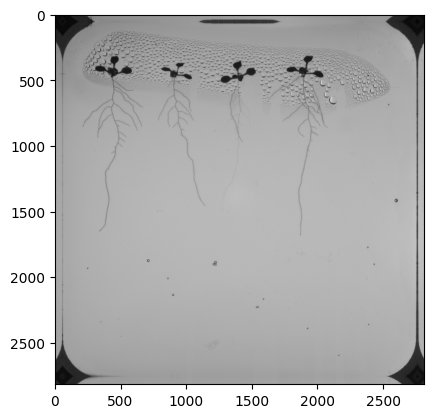